# Switching Linear Dynamical System Demo

Switching Linear Dynamical Systems (SLDS) provide a natural way of combining Linear Dynamical Systems with Hidden Markov Models. They allow us to approximate a system that has globally non-linear dynamics by a series of linear systems. A good reference for these types of systems is [Variational Inference for State Space models](https://www.cs.toronto.edu/~hinton/absps/switch.pdf) by Ghahramani and Hinton.

An LDS comprises $K$ discrete hidden states, which evolve according to a Markov chain. We'll call the hidden state $z$, and use the notation $z_t = k$ to mean that the system is in state $k$ at time $t$. The Markov chain for the hidden state is specified by a state-transition matrix $\mathbf{Q}$, where $\mathbf{Q}_{ij} = \mathbb{P}(z_t = j \mid z_{t-1} = i)$.

## Generative Model for SLDS

The generative model for an SLDS combines an HMM with a set of linear dynamical systems as follows. In addition to the discrete state, we have a continuous latent state $x_t \in \mathbb{R}^D$ and an observation $y_t \in \mathbb{R}^N$. Each discrete state ${1...K}$ is associated with a different dynamics matrix $\mathbf{A}_{k}$ and a different measurement matrix $\mathbf{C}_{k}$. Formally, we generate data from an SLDS as follows:

### Discrete State Update

At each time step, sample a new discrete state $z_t | z_{t - 1}$ with probabilities given by a Markov chain.

### Continuous State Update

Update the state using the dynamics matrix corresponding to the new discrete state:
$$
x_t = \mathbf{A}_{k} x_{t-1} + \mathbf{V}_{k} u_t + \mathbf{b}_{k} + \mathbf{w}_t
$$
where $\mathbf{A}_{z_t}$ is the dynamics matrix corresponding to discrete state $k$. $u_t$ is the input vector (specified by the user, not inferred by SSM) and $\mathbf{V}_{k}$ is the corresponding control matrix. The vector $\mathbf{b}_{k}$ is an offset vector, which can drive the dynamics in a particular direction. The term $\mathbf{w}_t$ is a noise term, which perturbs the dynamics. Most commonly these are modeled as zero-mean multivariate Gaussians, but one nice feature of SSM is that it supports many distributions for these noise terms. 

### Emission

We now make an observation of the state, according to the specified observation model. In the general case, the state controls the observation via a Generalized Linear Model:
$$
y_t \sim \mathbb{P}(\nu (\mathbf{C}_{k} x_t + \mathbf{d}_{k} + \mathbf{F}_{k} u_t + \mathbf{v}_{t}))
$$
where $\mathbb{P}$ is a probability distribution. The inner arguments form an affine measurement of the state, which is then passed through the inverse link function $\nu$. In this case, $\mathbf{C}_{k}$ is the measurement matrix corresponding to discrete state $k$, $\mathbf{d}_{k}$ is an offset or bias term corresponding to discrete state $k$, and $\mathbf{F}_{k}$ is called the feedthrough matrix or passthrough matrix (it passes the input directly to the emission). In the Gaussian case, the emission can simply be written as:
$$
y_t = \mathbf{C}_{k} x_t + \mathbf{d}_{k} + \mathbf{F}_{k} u_t + \mathbf{v}_t
$$
where $\mathbf{v}_t$ is a Gaussian r.v. 

This notebook demonstrates how to implement and fit a Switching Linear Dynamical System (SLDS) model using Gibbs Sampling implemented in JAX. 

## 1. Setup 

We'll start by importing the necessary libraries and setting up our environment.

In [1]:
import sys
import os
current_dir = os.path.dirname(os.path.abspath('__file__'))
parent_dir = os.path.dirname(current_dir)
sys.path.insert(0, parent_dir)
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import seaborn as sns
from jax import grad, jit, vmap, lax
from jaxtyping import Array, Float
from typing import Callable
from tensorflow_probability.substrates import jax as tfp
import equinox as eqx
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

tfd = tfp.distributions
tfb = tfp.bijectors
MVN = tfd.MultivariateNormalFullCovariance
MVNDiag = tfd.MultivariateNormalDiag

from dynamax import hidden_markov_model as hmm
from dynamax import linear_gaussian_ssm as lgssm
from models import SLDS
from slds_eqx.gibbs import fit_gibbs

# random seed for reproducibility
key = jr.PRNGKey(0)


## 2. Data Generation

To test our SLDS model and inference algorithm, we'll first generate synthetic data. This function creates a realistic SLDS model and samples data from it. Here's what it does:

1. Creates a transition matrix for the discrete states
2. Generates dynamics matrices for each state
3. Creates an emission matrix
4. Constructs the full SLDS model
5. Samples a sequence of discrete states, continuous latent states, and observations

Key components:
- `num_states`: Number of discrete states in the model
- `latent_dim`: Dimensionality of the continuous latent state
- `emission_dim`: Dimensionality of the observed data
- `num_timesteps`: Length of the time series to generate

The function returns the true SLDS model and the generated data (discrete states, continuous states, and observations).

In [1]:
def generate_synthetic_data(key, num_states, latent_dim, emission_dim, num_timesteps):
    #Create transition matrix
    p = jnp.arange((num_states)).astype(float)**10
    p /= p.sum()
    P = jnp.zeros((num_states, num_states))
    for k, p in enumerate(p[::-1]):
        P += jnp.roll(p * jnp.eye(num_states), k, axis=1)
    
    plt.imshow(P, vmin=0, vmax=1, cmap="Greys")
    plt.xlabel("next state")
    plt.ylabel("current state")
    plt.title("transition matrix")
    plt.colorbar()

    #Create dynamics matrices
    rot = lambda theta: jnp.array([[jnp.cos(theta), -jnp.sin(theta)],
                                   [jnp.sin(theta), jnp.cos(theta)]])
    angles = jnp.linspace(0, 2 * jnp.pi, num_states, endpoint=False)
    theta = -jnp.pi / 25
    As = jnp.array([0.8 * rot(theta) for _ in range(num_states)])
    bs = jnp.column_stack([jnp.cos(angles), jnp.sin(angles)])
    Qs = jnp.tile(0.001 * jnp.eye(latent_dim), (num_states, 1, 1))

    # Create emission matrix
    key, subkey = jr.split(key)
    C = jr.normal(subkey, (emission_dim, latent_dim))
    d = jnp.zeros(emission_dim)
    R = jnp.eye(emission_dim)

    # Create SLDS model
    log_P = tfb.SoftmaxCentered().inverse(P+1e-4)#
    log_Qs = tfb.Softplus(low=1e-5).inverse(vmap(jnp.diag)(Qs))
    log_R = tfb.Softplus(low=1e-5).inverse(jnp.diag(R))

    true_slds = SLDS(num_states, latent_dim, emission_dim, log_P, As, bs, log_Qs, C, d, log_R)
    
    # Sample from the model
    key, subkey = jr.split(key)
    zs, xs, ys = true_slds.sample(subkey, num_timesteps)
    return true_slds, zs, xs, ys

Here, we set the parameters for our SLDS:
- 5 discrete states
- Latent state of dimension 2
- Emissions of dimension 100
- 5000 time steps

These will serve as our ground truth data for evaluating the inference algorithm. The high-dimensional emissions (100D) from a low-dimensional latent state (2D) create a challenging and realistic scenario for our inference task.

Dynamics matrices created
Emission matrix created
log_P: [[ 9.1547365e+00  6.2796855e+00  2.3259559e+00  8.9797974e-03]
 [-8.9797974e-03  9.1457567e+00  6.2707057e+00  2.3169761e+00]
 [-2.3169761e+00 -2.3259559e+00  6.8287802e+00  3.9537296e+00]
 [-3.9537296e+00 -6.2707057e+00 -6.2796855e+00  2.8750508e+00]
 [-2.8750508e+00 -6.8287802e+00 -9.1457567e+00 -9.1547365e+00]]
log_Qs: [[-6.9173107 -6.9173107]
 [-6.9173107 -6.9173107]
 [-6.9173107 -6.9173107]
 [-6.9173107 -6.9173107]
 [-6.9173107 -6.9173107]]
log_R: [0.541309 0.541309 0.541309 0.541309 0.541309 0.541309 0.541309 0.541309
 0.541309 0.541309 0.541309 0.541309 0.541309 0.541309 0.541309 0.541309
 0.541309 0.541309 0.541309 0.541309 0.541309 0.541309 0.541309 0.541309
 0.541309 0.541309 0.541309 0.541309 0.541309 0.541309 0.541309 0.541309
 0.541309 0.541309 0.541309 0.541309 0.541309 0.541309 0.541309 0.541309
 0.541309 0.541309 0.541309 0.541309 0.541309 0.541309 0.541309 0.541309
 0.541309 0.541309 0.541309 0.541309 0.541309 0.

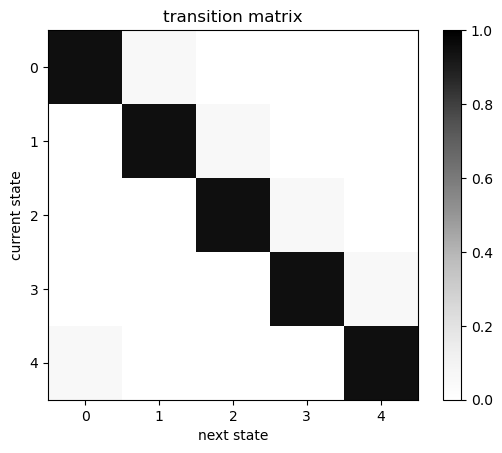

In [4]:
num_states, latent_dim, emission_dim, num_timesteps = 5, 2, 100, 5000
key, subkey = jr.split(key)
true_slds, true_zs, true_xs, ys = generate_synthetic_data(subkey, num_states, latent_dim, emission_dim, num_timesteps)

Let's take a closer look at our generated SLDS model and the synthetic data:

- `true_slds.transition_logits`: These are the log-probabilities of transitioning between discrete states. In SLDS theory, these logits define the Markov chain governing the switching process. The actual transition probabilities can be obtained by applying the softmax function to these logits.

- `true_zs.shape`: This shows the shape of our discrete state sequence. In SLDS, $z_t$ represents the active dynamical system at time $t$. The length of this sequence should match our specified `num_timesteps`.

- `true_xs.shape`: This displays the shape of our continuous latent state sequence. In SLDS, $x_t$ evolves according to the linear dynamical system specified by the current $z_t$. The first dimension should match `num_timesteps`, and the second should be our `latent_dim`.

- `ys.shape`: This shows the shape of our observation sequence. In SLDS, $y_t$ is generated from $x_t$ through the emission model. The first dimension should match `num_timesteps`, and the second should be our `emission_dim`.

- `true_zs`: This prints out the actual sequence of discrete states. In a well-specified SLDS, we expect to see periods where the system stays in one state, punctuated by transitions to other states.

In [5]:
print(f"Logits: {true_slds.transition_logits}")

Logits: [[ 9.1547365e+00  6.2796855e+00  2.3259559e+00  8.9797974e-03]
 [-8.9797974e-03  9.1457567e+00  6.2707057e+00  2.3169761e+00]
 [-2.3169761e+00 -2.3259559e+00  6.8287802e+00  3.9537296e+00]
 [-3.9537296e+00 -6.2707057e+00 -6.2796855e+00  2.8750508e+00]
 [-2.8750508e+00 -6.8287802e+00 -9.1457567e+00 -9.1547365e+00]]


In [6]:
print(true_zs.shape)
print(true_xs.shape)
print(ys.shape)
print(true_zs)

(5000,)
(5000, 2)
(5000, 100)
[1 1 1 ... 0 0 0]


In [7]:
plt.figure()
plt.imshow(ys[0].T, aspect="auto", interpolation="None")
plt.colorbar()

In [8]:
fig = plt.figure(figsize=(8, 8))
for k in range(num_states):
    plt.plot(*xs[zs==k].T, 'o', color=colors[k],
         alpha=0.75, markersize=3)

plt.plot(*xs[:1000].T, '-k', lw=0.5, alpha=0.2)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")

In [9]:
def plot_states_and_timeseries(zs, vs, vs_std=None, spc=5):
    T, dim = vs.shape
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    ax.imshow(zs[None, :],
              extent=(0, T, -spc, dim * spc),
              cmap=cmap,
              alpha=0.5,
              aspect="auto",
              vmax=len(colors)-1)
    ax.plot(vs + spc * jnp.arange(dim), '-k', lw=1)
    if vs_std is not None:
        for d in range(dim):
            ax.fill_between(jnp.arange(T),
                            vs[:, d] + spc * d - 2 * vs_std[:, d],
                            vs[:, d] + spc * d + 2 * vs_std[:, d],
                            color='k', alpha=0.25,
                            )
    ax.set_ylim(-spc, dim * spc)
    ax.set_yticks(jnp.arange(dim) * spc)
    ax.set_yticklabels(jnp.arange(dim))
    return fig, ax

fig, ax = plot_states_and_timeseries(zs[0], xs[0])
ax.set_xlim(0, 200)
ax.set_title("latent states")

fig, ax = plot_states_and_timeseries(zs[0], ys[0])
ax.set_xlim(0, 200)
ax.set_title("emissions")

In [10]:
#Intiliaze the model
def initialize_model(key, true_slds):
    # Slightly perturb the true parameters
    perturb = lambda x: x + 0.1 * jr.normal(key, x.shape)
    init_slds = SLDS(
        true_slds.num_states,
        true_slds.latent_dim,
        true_slds.emission_dim,
        perturb(true_slds.transition_logits),
        perturb(true_slds.dynamics_matrices),
        perturb(true_slds.dynamics_biases),
        perturb(true_slds.dynamics_diag_logvars),
        perturb(true_slds.emission_matrix),
        perturb(true_slds.emission_bias),
        perturb(true_slds.emission_diag_logvars)
    )
    return init_slds

In [11]:
key, subkey = jr.split(key)
init_slds = initialize_model(subkey, true_slds)

In [12]:
print(f"Logits: {init_slds.transition_logits}")

# [[ 9.102001   6.871491   4.011882   0.6626301]
#  [-0.6626301  8.439371   6.208861   3.3492517]
#  [-3.3492517 -4.011882   5.0901194  2.8596091]
#  [-2.8596091 -6.208861  -6.871491   2.2305102]
#  [-2.2305102 -5.0901194 -8.439371  -9.102001 ]]

Logits: [[ 9.074916    6.186605    2.2518263  -0.02338149]
 [ 0.04725956  9.297068    6.242708    2.4151518 ]
 [-2.440708   -2.31648     6.6948266   4.0269146 ]
 [-4.0571203  -6.45061    -6.11063     2.9656212 ]
 [-2.808271   -7.016446   -9.185459   -9.301804  ]]


In [13]:
# Fit the model
key, subkey = jr.split(key)
fitted_slds, lps, fitted_zs, fitted_xs = fit_gibbs(
    init_slds, subkey, ys, 
    initial_zs=jnp.asarray(jr.randint(subkey, (num_timesteps,), 0, num_states), dtype=jnp.int32),
    initial_xs=jr.normal(subkey, (num_timesteps, latent_dim)),
    num_iters=100, lr=1e-3, reg_schedule=lambda t: 1.0 * (0.99 ** t),
    param_update_iters=10
)

In [14]:
def compare_parameters(true_slds, fitted_slds):
    print("Transition Matrix:")
    print("True:", true_slds.transition_matrix)
    print("Fitted:", fitted_slds.transition_matrix)
    print("\nDynamics Matrices:")
    print("True:", true_slds.dynamics_matrices)
    print("Fitted:", fitted_slds.dynamics_matrices)
    print("\nEmission Matrix:")
    print("True:", true_slds.emission_matrix)
    print("Fitted:", fitted_slds.emission_matrix)

In [15]:
compare_parameters(true_slds, fitted_slds)

Transition Matrix:
True: [[9.4591337e-01 5.3362079e-02 1.0236459e-03 1.0090200e-04 9.9999997e-05]
 [9.9999997e-05 9.4591337e-01 5.3362079e-02 1.0236459e-03 1.0090200e-04]
 [1.0090200e-04 9.9999997e-05 9.4591337e-01 5.3362079e-02 1.0236459e-03]
 [1.0236459e-03 1.0090200e-04 9.9999997e-05 9.4591337e-01 5.3362079e-02]
 [5.3362079e-02 1.0236459e-03 1.0090200e-04 9.9999997e-05 9.4591337e-01]]
Fitted: [[8.71887624e-01 1.24201916e-01 3.41732707e-03 3.09525261e-04
  1.83603173e-04]
 [2.90922500e-04 8.68415415e-01 1.28618240e-01 2.53550825e-03
  1.39980461e-04]
 [3.11917771e-04 3.96837015e-04 8.74409735e-01 1.22934319e-01
  1.94718014e-03]
 [2.40495987e-03 2.13394946e-04 3.22827284e-04 9.16448116e-01
  8.06107149e-02]
 [1.01830907e-01 1.34404202e-03 1.65523248e-04 1.43775920e-04
  8.96515727e-01]]

Dynamics Matrices:
True: [[[ 0.7936918   0.10026659]
  [-0.10026659  0.7936918 ]]

 [[ 0.7936918   0.10026659]
  [-0.10026659  0.7936918 ]]

 [[ 0.7936918   0.10026659]
  [-0.10026659  0.7936918 ]]



In [16]:
print(f'True: {true_zs}')
print(f'Fitted: {fitted_zs}')

True: [1 1 1 ... 0 0 0]
Fitted: [4 4 0 ... 4 4 4]


In [17]:
# Discrete State Inference
# nmi compares mutual dependence and ari measures similarity in data clusterings
nmi = normalized_mutual_info_score(true_zs, fitted_zs)
ari = adjusted_rand_score(true_zs, fitted_zs)
print(f"Normalized Mutual Information: {nmi}")
print(f"Adjusted Rand Index: {ari}")

Normalized Mutual Information: 0.6043281756404119
Adjusted Rand Index: 0.5246006617381015


In [18]:
# Continuous State Inference
mse = jnp.mean((true_xs - fitted_xs)**2)
correlation = jnp.corrcoef(true_xs.ravel(), fitted_xs.ravel())[0, 1]
print(f"Mean Squared Error: {mse}")
print(f"Correlation: {correlation}")

Mean Squared Error: 0.4539651870727539
Correlation: 0.9891077280044556


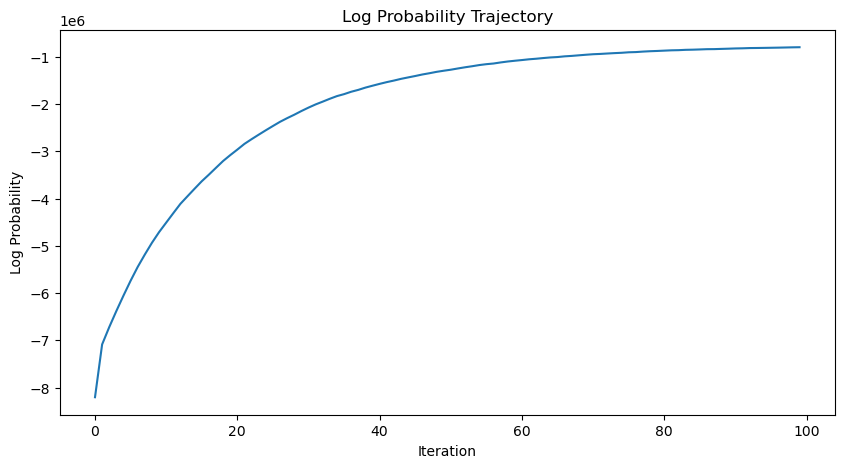

In [19]:
#Log Probability Trajectory
plt.figure(figsize=(10, 5))
plt.plot(lps)
plt.xlabel("Iteration")
plt.ylabel("Log Probability")
plt.title("Log Probability Trajectory")
plt.show()

In [20]:
# Visualize the results
def plot_states_and_timeseries(zs, xs, title):
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(zs[None, :], aspect="auto", cmap="Set3", interpolation="nearest")
    ax.plot(xs[:, 0], color="r", alpha=0.5)
    ax.plot(xs[:, 1], color="b", alpha=0.5)
    ax.set_title(title)
    plt.show()

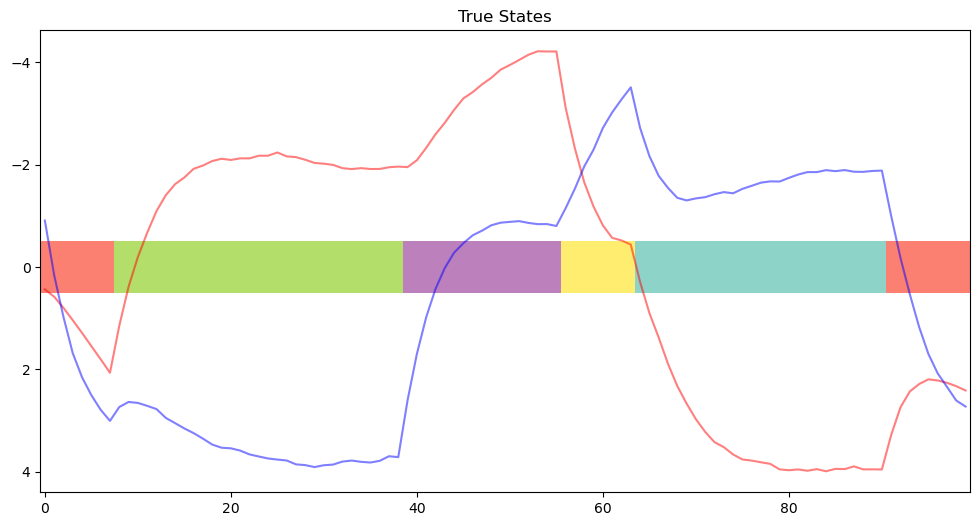

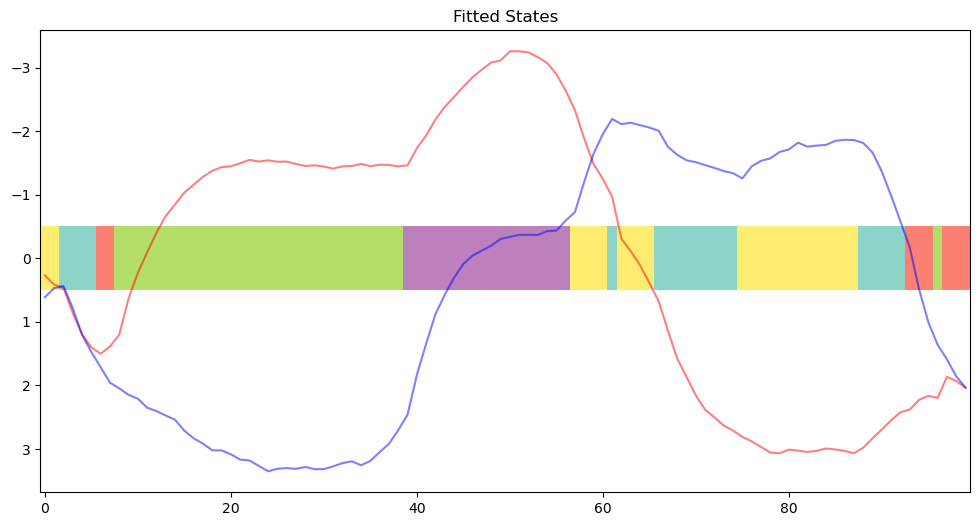

In [22]:
plot_states_and_timeseries(true_zs[:100], true_xs[:100], "True States")
plot_states_and_timeseries(fitted_zs[:100], fitted_xs[:100], "Fitted States")

In [23]:
# Checking for consistency across multiple runs
def run_multiple_fits(num_runs):
    results = []
    for i in range(num_runs):
        key = jr.PRNGKey(i)
        init_slds = initialize_model(key, true_slds)
        fitted_slds, lps, _, _ = fit_gibbs(init_slds, key, ys, 
                                           initial_zs=jr.randint(key, (num_timesteps,), 0, num_states),
                                           initial_xs=jr.normal(key, (num_timesteps, latent_dim)),
                                           num_iters=100)
        results.append(lps[-1])  # Final log probability
    return results

In [24]:
multiple_run_results = run_multiple_fits(10)
plt.figure(figsize=(10, 5))
plt.boxplot(multiple_run_results)
plt.title("Distribution of Final Log Probabilities Across Multiple Runs")
plt.show()

In [ ]:
# Checking performance with different initializations
def run_with_different_initializations():
    results = []
    for scale in [0.1, 1.0, 10.0]:
        key = jr.PRNGKey(int(scale * 100))
        perturb = lambda x: x + scale * jr.normal(key, x.shape)
        init_slds = SLDS(
            true_slds.num_states,
            true_slds.latent_dim,
            true_slds.emission_dim,
            perturb(true_slds.transition_logits),
            perturb(true_slds.dynamics_matrices),
            perturb(true_slds.dynamics_biases),
            perturb(true_slds.dynamics_diag_logvars),
            perturb(true_slds.emission_matrix),
            perturb(true_slds.emission_bias),
            perturb(true_slds.emission_diag_logvars)
        )
        fitted_slds, lps, _, _ = fit_gibbs(init_slds, key, ys, 
                                           initial_zs=jr.randint(key, (num_timesteps,), 0, num_states),
                                           initial_xs=jr.normal(key, (num_timesteps, latent_dim)),
                                           num_iters=100)
        results.append((scale, lps))
    return results

In [ ]:
init_results = run_with_different_initializations()
plt.figure(figsize=(10, 5))
for scale, lps in init_results:
    plt.plot(lps, label=f"Scale: {scale}")
plt.xlabel("Iteration")
plt.ylabel("Log Probability")
plt.title("Convergence with Different Initializations")
plt.legend()
plt.show()

In [ ]:
# Sensitivity to learning rate and regularization
def run_with_different_hyperparameters():
    results = []
    for lr in [1e-4, 1e-3, 1e-2]:
        for reg_scale in [0.1, 1.0, 10.0]:
            key = jr.PRNGKey(int(lr * 1e4 + reg_scale * 10))
            reg_schedule = lambda t: reg_scale * (0.99 ** t)
            fitted_slds, lps, _, _ = fit_gibbs(init_slds, key, ys, 
                                               initial_zs=jr.randint(key, (num_timesteps,), 0, num_states),
                                               initial_xs=jr.normal(key, (num_timesteps, latent_dim)),
                                               num_iters=100, lr=lr, reg_schedule=reg_schedule)
            results.append((lr, reg_scale, lps))
    return results

In [ ]:
hyper_results = run_with_different_hyperparameters()
plt.figure(figsize=(12, 8))
for lr, reg_scale, lps in hyper_results:
    plt.plot(lps, label=f"LR: {lr}, Reg: {reg_scale}")
plt.xlabel("Iteration")
plt.ylabel("Log Probability")
plt.title("Sensitivity to Hyperparameters")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()